In [1]:
import numpy as np
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
import netCDF4 as nc

ds = nc.Dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/Amazon_cropped/2002/MCD06COSP_D3_MODIS.A2002354.062.2022125082709.nc')
print(ds.groups.keys())

dict_keys(['Cloud_Top_Pressure', 'Cloud_Mask_Fraction', 'Cloud_Mask_Fraction_Low', 'Cloud_Mask_Fraction_Mid', 'Cloud_Mask_Fraction_High', 'Cloud_Optical_Thickness_Liquid', 'Cloud_Optical_Thickness_Ice', 'Cloud_Optical_Thickness_Total', 'Cloud_Optical_Thickness_PCL_Liquid', 'Cloud_Optical_Thickness_PCL_Ice', 'Cloud_Optical_Thickness_PCL_Total', 'Cloud_Optical_Thickness_Log10_Liquid', 'Cloud_Optical_Thickness_Log10_Ice', 'Cloud_Optical_Thickness_Log10_Total', 'Cloud_Particle_Size_Liquid', 'Cloud_Particle_Size_Ice', 'Cloud_Particle_Size_PCL_Liquid', 'Cloud_Particle_Size_PCL_Ice', 'Cloud_Water_Path_Liquid', 'Cloud_Water_Path_Ice', 'Cloud_Water_Path_PCL_Liquid', 'Cloud_Water_Path_PCL_Ice'])


In [11]:
ds = nc.Dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/2002/MCD06COSP_D3_MODIS.A2002361.062.2022125081935.nc')
print(ds.groups.keys())

dict_keys(['Solar_Zenith', 'Solar_Azimuth', 'Sensor_Zenith', 'Sensor_Azimuth', 'Cloud_Top_Pressure', 'Cloud_Mask_Fraction', 'Cloud_Mask_Fraction_Low', 'Cloud_Mask_Fraction_Mid', 'Cloud_Mask_Fraction_High', 'Cloud_Optical_Thickness_Liquid', 'Cloud_Optical_Thickness_Ice', 'Cloud_Optical_Thickness_Total', 'Cloud_Optical_Thickness_PCL_Liquid', 'Cloud_Optical_Thickness_PCL_Ice', 'Cloud_Optical_Thickness_PCL_Total', 'Cloud_Optical_Thickness_Log10_Liquid', 'Cloud_Optical_Thickness_Log10_Ice', 'Cloud_Optical_Thickness_Log10_Total', 'Cloud_Particle_Size_Liquid', 'Cloud_Particle_Size_Ice', 'Cloud_Particle_Size_PCL_Liquid', 'Cloud_Particle_Size_PCL_Ice', 'Cloud_Water_Path_Liquid', 'Cloud_Water_Path_Ice', 'Cloud_Water_Path_PCL_Liquid', 'Cloud_Water_Path_PCL_Ice', 'Cloud_Retrieval_Fraction_Liquid', 'Cloud_Retrieval_Fraction_Ice', 'Cloud_Retrieval_Fraction_Total', 'Cloud_Retrieval_Fraction_PCL_Liquid', 'Cloud_Retrieval_Fraction_PCL_Ice', 'Cloud_Retrieval_Fraction_PCL_Total'])


In [4]:
for group_name in ['Cloud_Mask_Fraction', 'Cloud_Optical_Thickness_Total']:
    group = ds.groups[group_name]
    print(f"\n{group_name}: {list(group.variables.keys())}")


Cloud_Mask_Fraction: ['Mean', 'Standard_Deviation', 'Sum', 'Pixel_Counts', 'Sum_Squares']

Cloud_Optical_Thickness_Total: ['Mean', 'Standard_Deviation', 'Sum', 'Pixel_Counts', 'Sum_Squares', 'JHisto_vs_Cloud_Top_Pressure']


In [16]:
ds = nc.Dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/2002/MCD06COSP_D3_MODIS.A2002361.062.2022125081935.nc')

In [17]:
ds

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    YAML_config: grid_settings:
  gridsize: 1
  projection: conformal
  lat_in: Latitude
  lon_in: Longitude
  lat_out: Latitude
  lon_out: Longitude
  fill_value: -999

variable_settings:

  - name_in: Solar_Zenith
    name_out: Solar_Zenith
    attributes: 
    - name: long_name
      value: Solar Zenith Angle (Cell to Sun) for Daytime Scenes
    - name: units
      value: degrees
    - name: _FillValue
      value: -999.0
    - name: valid_min
      value: 0.0
    - name: valid_max
      value: 180.0
    - name: scale_factor
      value: 1.0
    - name: add_offset
      value: 0.0
    masks:
    - Mask_Day

  - name_in: Solar_Azimuth
    name_out: Solar_Azimuth
    attributes: 
    - name: long_name
      value: Solar Azimuth Angle (Cell to Sun) for Daytime Scenes
    - name: units
      value: degrees
    - name: _FillValue
      value: -999.0
    - name: valid_min
      value: -180.0
    - name: valid_max

## ab hier mit ENSO experimentiert

In [8]:
ds2=xr.open_dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/merged/CWP_liq.nc')
ds2

<xarray.Dataset> Size: 414MB
Dimensions:             (time: 8621, longitude: 40, latitude: 30)
Coordinates:
  * time                (time) datetime64[ns] 69kB 2002-07-04 ... 2026-03-11
  * longitude           (longitude) float64 320B -79.5 -78.5 ... -41.5 -40.5
  * latitude            (latitude) float64 240B -19.5 -18.5 -17.5 ... 8.5 9.5
Data variables:
    Mean                (time, longitude, latitude) float64 83MB ...
    Standard_Deviation  (time, longitude, latitude) float64 83MB ...
    Sum                 (time, longitude, latitude) float64 83MB ...
    Pixel_Counts        (time, longitude, latitude) float64 83MB ...
    Sum_Squares         (time, longitude, latitude) float64 83MB ...
Attributes:
    long_name:     Cloud Water Path for Liquid Water Clouds (3.7 micron Retri...
    units:         g/m^2
    _FillValue:    -999.0
    valid_min:     0.0
    valid_max:     3000.0
    scale_factor:  1.0
    add_offset:    0.0

In [6]:
ds_m=ds2.mean(dim='latitude')
ds_mean=ds_m.mean(dim='longitude')
ds_mean=ds_mean.sel(time=slice('2003-01-01','2024-12-31'))
ds_mean

<xarray.Dataset> Size: 384kB
Dimensions:             (time: 8009)
Coordinates:
  * time                (time) datetime64[ns] 64kB 2003-01-01 ... 2024-12-31
Data variables:
    Mean                (time) float64 64kB 0.3395 0.3683 ... 0.1993 0.1776
    Standard_Deviation  (time) float64 64kB 0.3009 0.3133 ... 0.2682 0.2445
    Sum                 (time) float64 64kB 155.6 191.8 140.4 ... 103.7 69.72
    Pixel_Counts        (time) float64 64kB 474.0 529.1 428.3 ... 513.7 383.3
    Sum_Squares         (time) float64 64kB 130.4 163.6 122.6 ... 86.3 60.35
Attributes:
    long_name:     Cloud Fraction from Cloud Mask (Low Clouds, CTP GE 680 hPa...
    units:         none
    _FillValue:    -999.0
    valid_min:     0.0
    valid_max:     1.0
    scale_factor:  1.0
    add_offset:    0.0

In [7]:
# Create complete date range
full_range = pd.date_range('2003-01-01', '2024-12-31', freq='D')

# Compare with actual dates in dataset
existing = pd.DatetimeIndex(ds_mean['time'].values)  # or whatever your time dim is called
missing = full_range.difference(existing)

print(f"Missing days: {len(missing)}")
print(missing)

Missing days: 27
DatetimeIndex(['2009-01-23', '2018-05-23', '2018-08-25', '2018-08-26',
               '2018-09-03', '2018-09-16', '2018-09-30', '2018-10-03',
               '2018-10-30', '2018-11-13', '2018-12-05', '2018-12-11',
               '2018-12-12', '2018-12-17', '2018-12-24', '2018-12-25',
               '2018-12-26', '2018-12-30', '2019-01-06', '2019-01-30',
               '2020-03-06', '2020-04-17', '2020-05-23', '2020-08-08',
               '2020-08-11', '2020-08-12', '2020-08-16'],
              dtype='datetime64[us]', freq=None)


In [8]:
# Einlesen
df = pd.read_csv(
    "meiv2.data",
    sep=r'\s+',
    header=0,
    skipfooter=4,
    engine='python',
    na_values=[-999, -999.0]
)

df.columns = ["year", "DJ", "JF", "FM", "MA", "AM", "MJ", "JJ", "JA", "AS", "SO", "ON", "ND"]

# Zweiter Monat pro Saison → Monatsnummer
season_to_month = {
    "DJ": 1, "JF": 2, "FM": 3, "MA": 4, "AM": 5, "MJ": 6,
    "JJ": 7, "JA": 8, "AS": 9, "SO": 10, "ON": 11, "ND": 12
}

In [9]:
ds_rm = ds_mean.rolling(time=90, center=True).mean()

In [10]:
da_filled = ds_mean['Mean'].interpolate_na(dim='time')
y = da_filled.values
x = np.arange(len(ds_mean.Mean))


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
trend = slope * x + intercept

In [11]:
daily_dates = [
    pd.date_range(row.date, periods=pd.Timestamp(row.date).days_in_month, freq='D')
    for row in df_long.itertuples()
]

# Repeat each row for every day in its month
df_daily = df_long.loc[df_long.index.repeat([len(d) for d in daily_dates])].copy()
df_daily['date'] = [d for dates in daily_dates for d in dates]
df_daily = df_daily.reset_index(drop=True)

df_daily = df_daily[~df_daily['date'].isin(missing)]

df_sd = df_daily.query("'2003-01-01' <= date <= '2024-12-31'")
df_sd

NameError: name 'df_long' is not defined

In [ ]:
fig2, ax2 = plt.subplots(figsize=(14, 4))
ax2.plot(ds_rm.time, ds_rm.Mean, label='CMF_low' , color='black')
#ax2.plot(ds_rm.time, trend, label=f'Trend: {3650*slope:.4f}/decade', color='red')
#ax.fill_between(ds_rm.time, 1, -1,
#                where=df_sd["mei"] > 0, color="red", alpha=0.3, label="El Niño")
#ax.fill_between(ds_rm.time, 1, -1,
#                where=df_sd["mei"] < 0, color="blue", alpha=0.3, label="La Niña")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_long["date"], df_long["mei"], linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(df_long["date"], df_long["mei"], 0,
                where=df_long["mei"] > 0, color="red", alpha=0.3, label="El Niño")
ax.fill_between(df_long["date"], df_long["mei"], 0,
                where=df_long["mei"] < 0, color="blue", alpha=0.3, label="La Niña")

ax.set_ylabel("MEI")
ax.legend()
plt.tight_layout()
#plt.savefig("mei_timeseries.png", dpi=150)
plt.show()

plt.legend()
plt.show()
print(f'R²={r_value**2}')
print(f'P={p_value}')

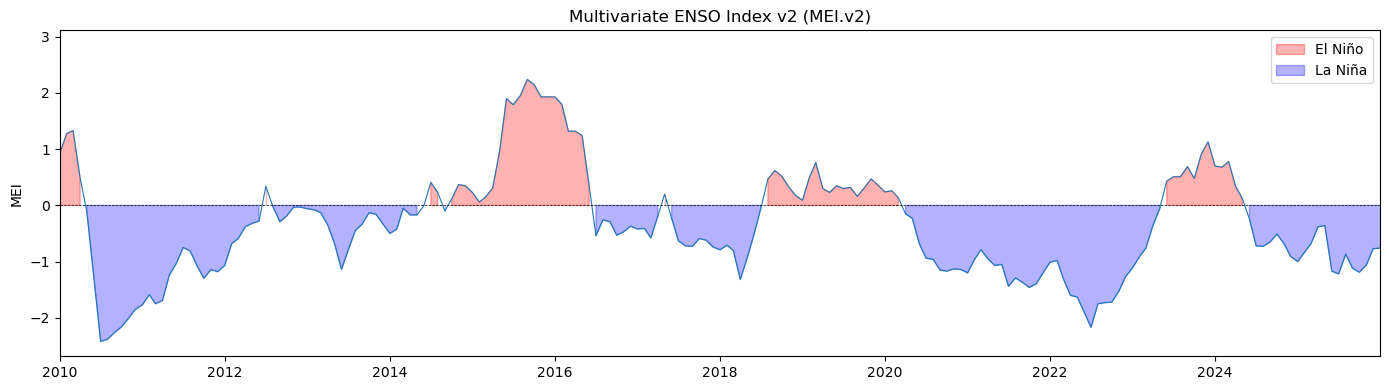

In [14]:
# Wide → Long, dann Datum bauen
df_long = df.melt(id_vars="year", var_name="season", value_name="mei")
df_long["month"] = df_long["season"].map(season_to_month)
df_long["date"] = pd.to_datetime(df_long[["year", "month"]].assign(day=1))
df_long = df_long.dropna(subset=["mei"]).sort_values("date")

# Plotten
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_long["date"], df_long["mei"], linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(df_long["date"], df_long["mei"], 0,
                where=df_long["mei"] > 0, color="red", alpha=0.3, label="El Niño")
ax.fill_between(df_long["date"], df_long["mei"], 0,
                where=df_long["mei"] < 0, color="blue", alpha=0.3, label="La Niña")
ax.set_xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2025-12-31"))
ax.set_title("Multivariate ENSO Index v2 (MEI.v2)")
ax.set_ylabel("MEI")
ax.legend()
plt.tight_layout()
#plt.savefig("mei_timeseries.png", dpi=150)
plt.show()

In [113]:
slope3, intercept3, r_value3, p_value3, std_err3 = stats.linregress(df_sd['mei'], ds_rm['Mean'])
trend3 = slope3 * df_sd['mei'] + intercept3

print(slope3)
print

nan


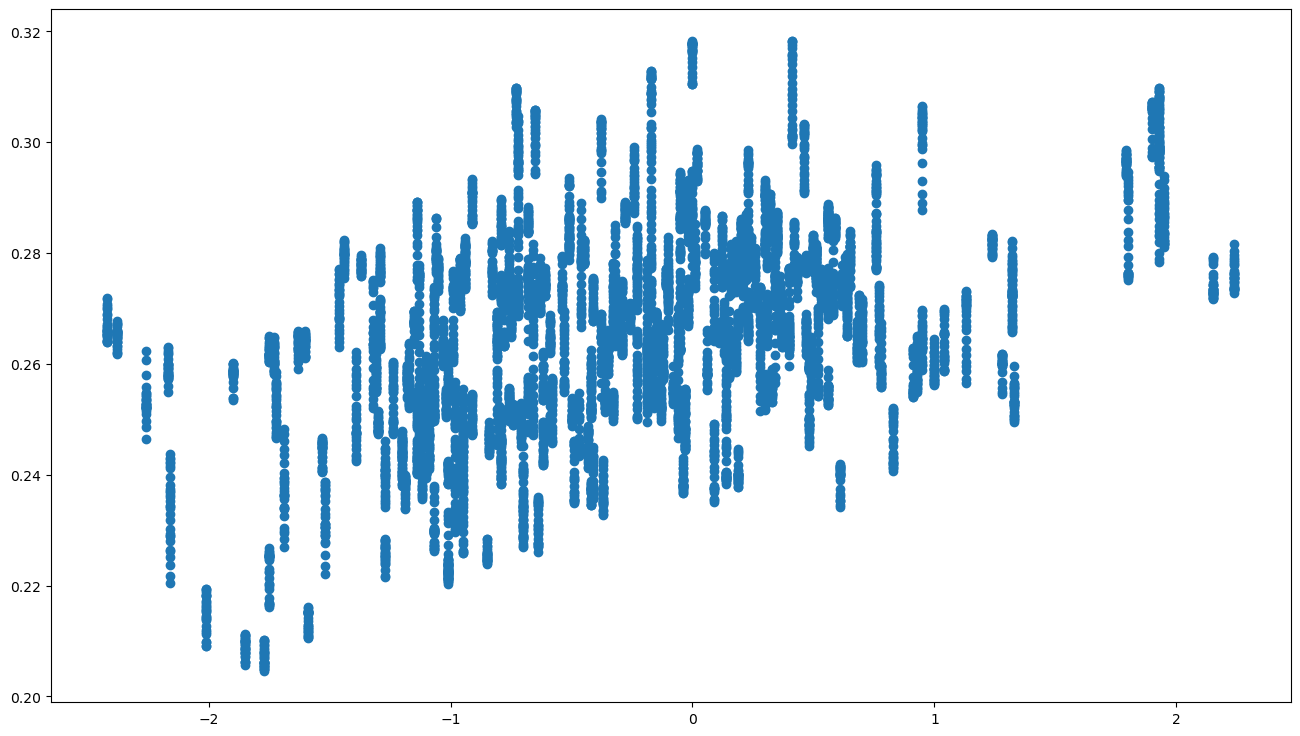

In [111]:
plt.figure(figsize=(16,9))
plt.scatter(df_sd['mei'], ds_rm['Mean'])
plt.plot(df_sd['mei'], trend3)

plt.show()
